<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Analytical_Fourier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Heat Conduction Profiles ---
        x   Density  Temperature     HeatFlux
0    0.00  1.195655     0.704337  1888.965643
1    0.01  1.190405     0.707444  1888.965643
2    0.02  1.185213     0.710543  1888.965643
3    0.03  1.180076     0.713636  1888.965643
4    0.04  1.174995     0.716722  1888.965643
..    ...       ...          ...          ...
96   0.96  0.861239     0.977829  1888.965643
97   0.97  0.858922     0.980467  1888.965643
98   0.98  0.856621     0.983101  1888.965643
99   0.99  0.854335     0.985731  1888.965643
100  1.00  0.852065     0.988358  1888.965643

[101 rows x 4 columns]


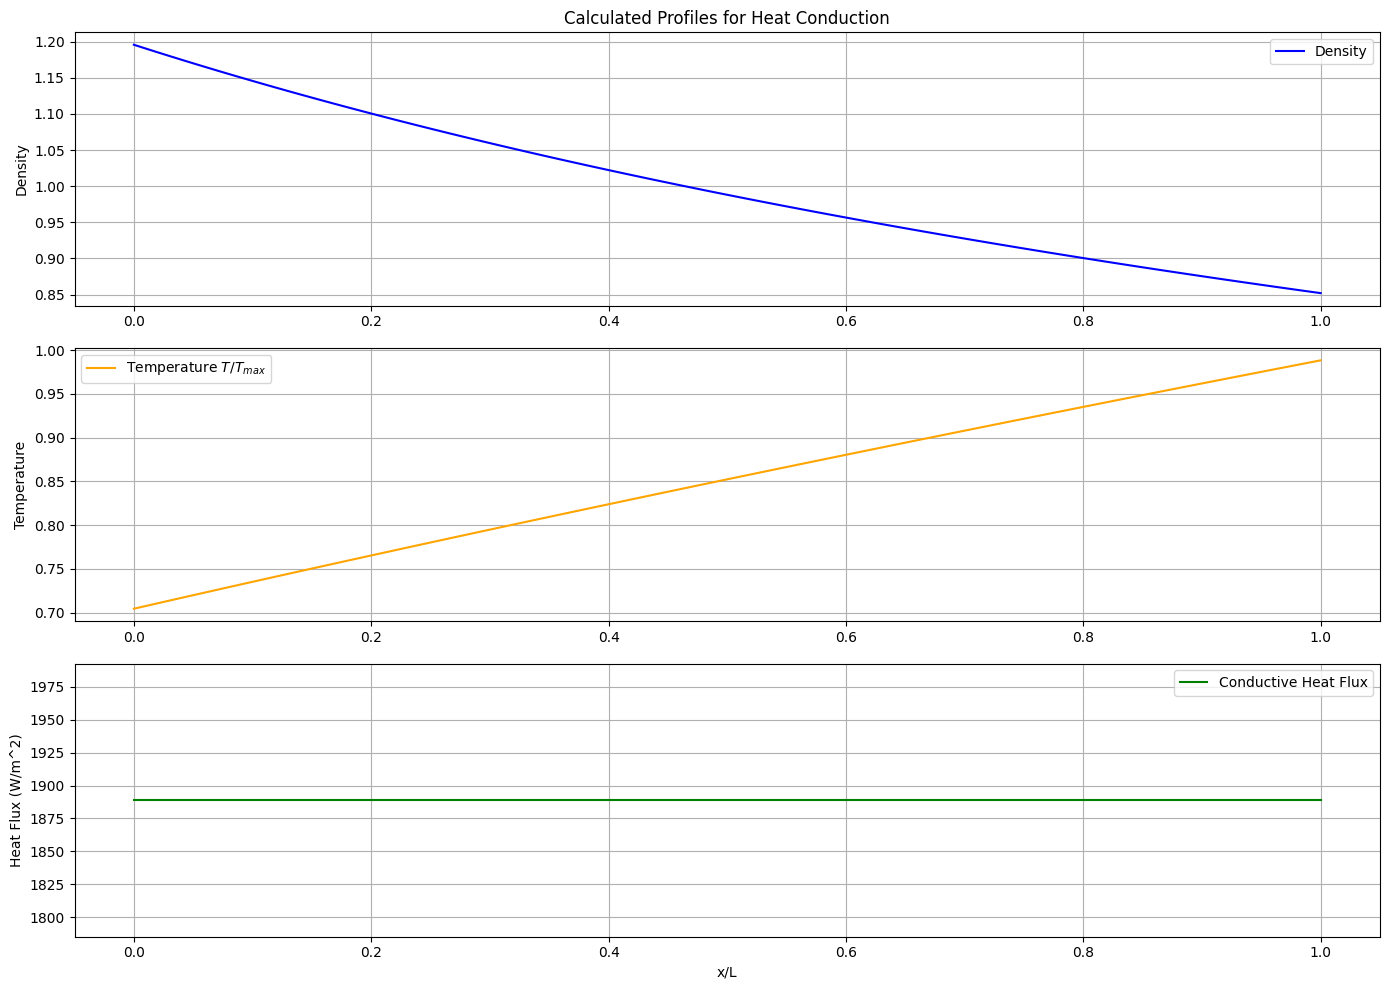

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Constants
# Boltzmann constant (J/K)
kb = 1.38064852e-23
# Ratio of specific heats (monoatomic gas)
k = 5. / 3.
# Prandtl number
pr = 2. / 3.
# Temperature ratio T_min / T_max
r = 223.15 / 323.15
# Knudsen number
kn = 0.0237
# A parameter related to frequency, seems to be large
fr = 1e9
# A derived heat transfer parameter
q = 1.996 * (k / (k + 1)) * (kn / pr)

# Initial guess for the iterative solution for dimensionless temperatures at the boundaries
# t1_0 is at the hot boundary (x=1), t0_0 is at the cold boundary (x=0)
t1_0 = 1 + (2 / 3) * q * ((r**(3/2) - 1.))
t0_0 = r * (1 - (2 / 3) * q * (r**(3/2) - 1) / (r**(3/2)))

# Iteratively solve for the boundary temperatures until convergence
eps = 1.
while eps > 1e-12:
    t1 = 1 + (2. / 3.) * q / np.sqrt(t1_0) * (t0_0**(3./2.) - t1_0**(3./2.))
    t0 = r + np.sqrt(t1_0 / t0_0) * (1. - t1_0)
    # Check for convergence
    eps = max(abs(t0 - t0_0), abs(t1 - t1_0))
    # Update values for the next iteration
    t0_0 = t0
    t1_0 = t1

# Parameters for calculating the profiles based on the converged boundary temperatures
a = t1**(3./2.) - t0**(3./2.)
b = t0**(3./2.)
c = -2. / fr

# Generate profiles across the domain
N = 101 # Number of points
z_vals = np.linspace(0, 1, N) # Dimensionless position from 0 to 1

# Calculate Temperature profile
tt = a * z_vals + b
T_vals = tt ** (2. / 3.)

# Calculate Heat Flux profile
# Note: This is a dimensionless flux
flux = (2. / 3.) * a * (tt ** (-1. / 3.)) * np.sqrt(T_vals)

# Calculate Density profile
ro = np.exp(-(2./3.) * np.log(tt) + 3 * tt ** (1./3.) * c / a)
# Normalize the density profile
ro1 = ro * N / np.sum(ro)

# Constants for converting dimensionless heat flux to physical units (qqq2)
Th = 373.15  # Reference temperature (K)
gc = 208.1   # Gas constant for Argon (J/kgK)
dm = 3.63e-10 # Atomic diameter (m)
vth = np.sqrt(2 * gc * Th) # Thermal velocity (m/s)
rmass = 6.63e-26 # Mass of Argon atom (kg)
rl = 1e-3 # Characteristic length (m)
rl0 = kn * rl # Mean free path (m)
rn0 = 1 / (np.sqrt(2.) * np.pi * dm**2 * rl0) # Number density (1/m^3)
rho = rmass * rn0 # Mass density (kg/m^3)
cp = 523.1 # Specific heat at constant pressure (J/kgK)
# Thermal conductivity
lambdah = (15. / 32.) * cp * vth * rl0 * rho * np.sqrt(np.pi)
# Physical heat flux (W/m^2)
qqq2 = lambdah * flux * Th / rl

# Create a pandas DataFrame for the results
df = pd.DataFrame({
    "x": z_vals,
    "Density": ro1,
    "Temperature": T_vals,
    "HeatFlux": qqq2
})

# Print the DataFrame to the console
print("--- Heat Conduction Profiles ---")
print(df)

# Plotting the results
plt.figure(figsize=(14, 10))

# Plot Density
plt.subplot(3, 1, 1)
plt.plot(z_vals, ro1, label='Density', color='blue')
plt.ylabel("Density")
plt.title("Calculated Profiles for Heat Conduction")
plt.grid(True)
plt.legend()

# Plot Temperature
plt.subplot(3, 1, 2)
plt.plot(z_vals, T_vals, label='Temperature $T/T_{max}$', color='orange')
plt.ylabel("Temperature")
plt.grid(True)
plt.legend()

# Plot Heat Flux
plt.subplot(3, 1, 3)
plt.plot(z_vals, qqq2, label='Conductive Heat Flux', linestyle='-', color='green')
plt.xlabel("x/L")
plt.ylabel("Heat Flux (W/m^2)")
plt.grid(True)
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()
